# Chemotherapy response prediction

Trains a 5-fold cross-validated logistic-regression ensemble on the TransNEO
chemotherapy cohort, then evaluates the held-out predictions plus IMPRESS and
PBCP. Adapted from `scr/new_tras_clusters/auc_final_chemo_v3.py`.

**Pipeline per fold:**
`MinMaxScaler → SelectKBest(f_classif, k='all') → LogisticRegression(C=100, L1)`

**Inputs**
- `../../clustering/data/transneo_chemo_cluster_props.csv` — 93 TransNEO chemo slides × 11 ST cluster proportions (training).
- `../../clustering/data/impress_chemo_cluster_props.csv` — 64 IMPRESS chemo slides (external test).
- `../../clustering/data/pbcp_chemo_cluster_props.csv` — 19 PBCP chemo slides (external test).
- `../data/response_labels.csv` — pCR / non-pCR per slide.

**Output**
- `../models/chemo_ensemble.joblib` — fitted 5-fold ensemble pipeline.

## Setup

In [1]:
import sys
sys.path.append("../lib")

import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from model_classes import EnsembleModel, FeatureAligner

import warnings; warnings.filterwarnings("ignore")

def per_patient_props(per_domain_csv):
    """Sum proportion_of_spots per (slide_name, predicted_cluster), then pivot."""
    d = pd.read_csv(per_domain_csv)
    return (d.groupby(['slide_name', 'predicted_cluster'])['proportion_of_spots']
              .sum().reset_index()
              .pivot(index='slide_name', columns='predicted_cluster', values='proportion_of_spots')
              .fillna(0))

## Load training data — TransNEO chemo

In [2]:
labels = pd.read_csv("../data/response_labels.csv", index_col=0)
labels.index = labels.index.astype(str)

X_train = per_patient_props("../../clustering/data/transneo_chemo_per_domain.csv")
X_train.index = X_train.index.astype(str)

# Use only slides that have a Response label
keep = X_train.index.intersection(labels[labels["Response"].notna()].index)
X_train = X_train.loc[keep]
y_train = labels.loc[keep, "Response"].astype(int).values
print(f"TransNEO chemo: {X_train.shape[0]} slides, {X_train.shape[1]} features, prevalence={y_train.mean():.3f}")

TransNEO chemo: 93 slides, 10 features, prevalence=0.226


## Train — 5-fold stratified CV

In [3]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
param_grid = {
    "select__k":      ["all"],
    "logreg__penalty": ["l1"],
    "logreg__C":       [100],
    "logreg__solver":  ["saga"],
}

models, cv_scores, cv_y, cv_idx = [], [], [], []
for tr, te in kf.split(X_train, y_train):
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("select", SelectKBest(f_classif)),
        ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    gs = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc",
                      refit="logreg__C").fit(X_train.iloc[tr], y_train[tr])
    models.append(gs.best_estimator_)
    proba = gs.best_estimator_.predict_proba(X_train.iloc[te])[:, 1]
    cv_scores.extend(proba); cv_y.extend(y_train[te]); cv_idx.extend(X_train.iloc[te].index)

cv_pred = pd.DataFrame({"y_true": cv_y, "y_proba": cv_scores}, index=cv_idx)
auc_train_cv = roc_auc_score(cv_pred["y_true"], cv_pred["y_proba"])
print(f"TransNEO 5-fold CV AUC: {auc_train_cv:.4f}")

TransNEO 5-fold CV AUC: 0.7530


## Build the final ensemble + save

In [4]:
ensemble_pipeline = Pipeline([
    ("aligner", FeatureAligner(expected_features=list(X_train.columns),
                                fill_values=X_train.mean().to_dict())),
    ("ensemble", EnsembleModel(models=models)),
])
joblib.dump(ensemble_pipeline, "../models/chemo_ensemble.joblib")
print("Saved ../models/chemo_ensemble.joblib")

Saved ../models/chemo_ensemble.joblib


## Evaluate on the external cohorts

IMPRESS and PBCP — load per-patient cluster proportions, intersect with
Response labels, score with the saved ensemble pipeline.

In [5]:
def evaluate(per_domain_csv, cohort_name):
    Xc = per_patient_props(per_domain_csv)
    Xc.index = Xc.index.astype(str)
    common = Xc.index.intersection(labels[labels["Response"].notna()].index)
    if len(common) == 0:
        return pd.DataFrame()
    Xc = Xc.loc[common]
    yc = labels.loc[common, "Response"].astype(int).values
    proba = ensemble_pipeline.predict_proba(Xc)
    auc = roc_auc_score(yc, proba) if len(np.unique(yc)) > 1 else float("nan")
    print(f"{cohort_name:<10} n={len(yc):>3}, prevalence={yc.mean():.3f}, AUC={auc:.4f}")
    return pd.DataFrame({"y_true": yc, "y_proba": proba, "Cohort": cohort_name}, index=common)

cv_pred["Cohort"] = "TransNEO (5-fold CV)"
print(f"TransNEO   n={len(cv_pred):>3}, prevalence={cv_pred['y_true'].mean():.3f}, AUC={auc_train_cv:.4f}")
df_impress = evaluate("../../clustering/data/impress_chemo_per_domain.csv", "IMPRESS")
df_pbcp    = evaluate("../../clustering/data/pbcp_chemo_per_domain.csv",    "PBCP")

all_pred = pd.concat([cv_pred, df_impress, df_pbcp])
all_pred.head()

TransNEO   n= 93, prevalence=0.226, AUC=0.7530
IMPRESS    n= 64, prevalence=0.422, AUC=0.7492
PBCP       n= 19, prevalence=0.263, AUC=0.8857


,y_true,y_proba,Cohort
BC_00012_470662,1,0.627871,TransNEO (5-fold CV)
BC_00014_470664,0,0.627871,TransNEO (5-fold CV)
BC_00037_473337,1,0.627871,TransNEO (5-fold CV)
BC_00038_473338,0,0.627871,TransNEO (5-fold CV)
BC_00039_473339,0,0.275406,TransNEO (5-fold CV)


## AUC summary

In [6]:
rows = []
for c, g in all_pred.groupby("Cohort"):
    rows.append({"Cohort": c, "n": len(g), "Prevalence": g["y_true"].mean(),
                  "AUC": roc_auc_score(g["y_true"], g["y_proba"]) if len(np.unique(g["y_true"])) > 1 else float("nan")})
summary = pd.DataFrame(rows).sort_values("Cohort").reset_index(drop=True)
summary.round(3)

,Cohort,n,Prevalence,AUC
0,IMPRESS,64,0.422,0.749
1,PBCP,19,0.263,0.886
2,TransNEO (5-fold CV),93,0.226,0.753


## ROC curves

One panel per cohort: the empirical cluster ROC (solid) plus a
binormal-smoothed overlay (dashed). The AUC shown is always the empirical
`roc_auc_score` — the binormal fit is for visualization only.

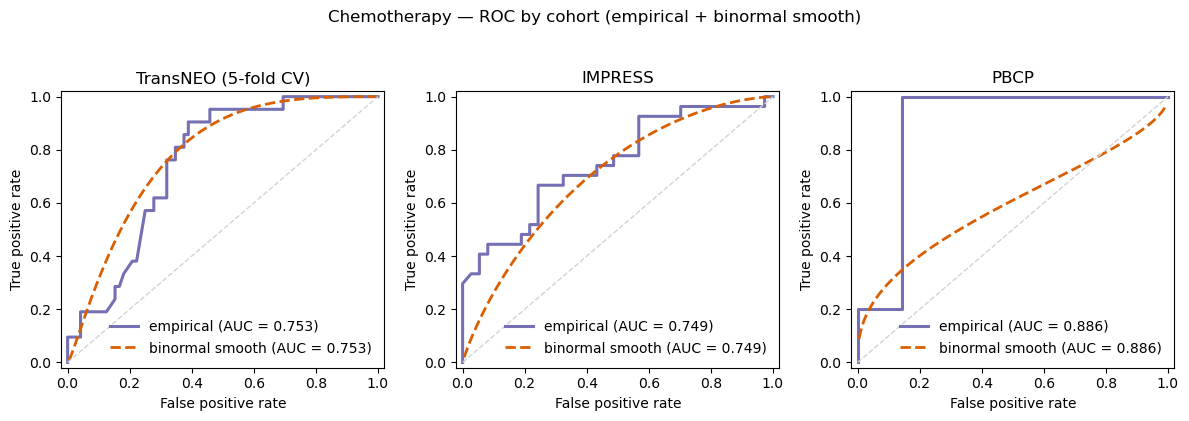

TransNEO (5-fold CV)   binormal a = +1.384, b = 1.458
IMPRESS                binormal a = +0.783, b = 1.109
PBCP                   binormal a = +0.280, b = 0.630


In [7]:
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.metrics import roc_curve


def binormal_roc(y_true, y_score, n_points=200):
    """Binormal-smoothed ROC curve.

    Assumes positive-class scores ~ N(mu1, sd1**2) and negative-class scores
    ~ N(mu0, sd0**2). The smoothed ROC is ROC(t) = Phi(a + b * Phi^-1(t)) with
    a = (mu1 - mu0) / sd1 and b = sd0 / sd1. mu/sd are estimated by method of
    moments (per-class sample mean and std). Returns (fpr, tpr, a, b); the AUC
    is deliberately NOT returned -- report the empirical roc_auc_score instead,
    since the smooth is for visualization only.
    """
    y_true  = np.asarray(y_true)
    y_score = np.asarray(y_score)
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    mu1, sd1 = pos.mean(), pos.std(ddof=0)
    mu0, sd0 = neg.mean(), neg.std(ddof=0)
    a = (mu1 - mu0) / sd1
    b = sd0 / sd1
    fpr = np.linspace(0, 1, n_points + 2)[1:-1]   # drop exact 0/1: Phi^-1 -> +-inf
    tpr = norm.cdf(a + b * norm.ppf(fpr))
    return fpr, tpr, a, b


cohorts = ["TransNEO (5-fold CV)", "IMPRESS", "PBCP"]
checks = []

fig, axes = plt.subplots(1, len(cohorts), figsize=(4 * len(cohorts), 4))
for ax, cohort in zip(axes, cohorts):
    g = all_pred[all_pred["Cohort"] == cohort]
    auc = roc_auc_score(g["y_true"], g["y_proba"])          # empirical AUC, from data

    fpr, tpr, _ = roc_curve(g["y_true"], g["y_proba"])
    ax.plot(fpr, tpr, color="#7570B3", lw=2.2, label=f"empirical (AUC = {auc:.3f})")

    fpr_s, tpr_s, a, b = binormal_roc(g["y_true"], g["y_proba"])
    ax.plot(fpr_s, tpr_s, color="#D95F02", lw=2, ls="--",
            label=f"binormal smooth (AUC = {auc:.3f})")
    checks.append((cohort, a, b))

    ax.plot([0, 1], [0, 1], color="lightgray", lw=1, ls="--")
    ax.set(title=cohort, xlabel="False positive rate", ylabel="True positive rate",
           xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
    ax.legend(loc="lower right", frameon=False)
fig.suptitle("Chemotherapy \u2014 ROC by cohort (empirical + binormal smooth)", y=1.04)
fig.tight_layout()
plt.show()

# Sanity check: report (a, b); flag b far from 1 (improper / non-concave binormal ROC)
for cohort, a, b in checks:
    flag = "  [WARN: |b-1| > 0.5 -- binormal ROC may be improper / non-concave]" if abs(b - 1) > 0.5 else ""
    print(f"{cohort:<22} binormal a = {a:+.3f}, b = {b:.3f}{flag}")